# Comparison Smoothing

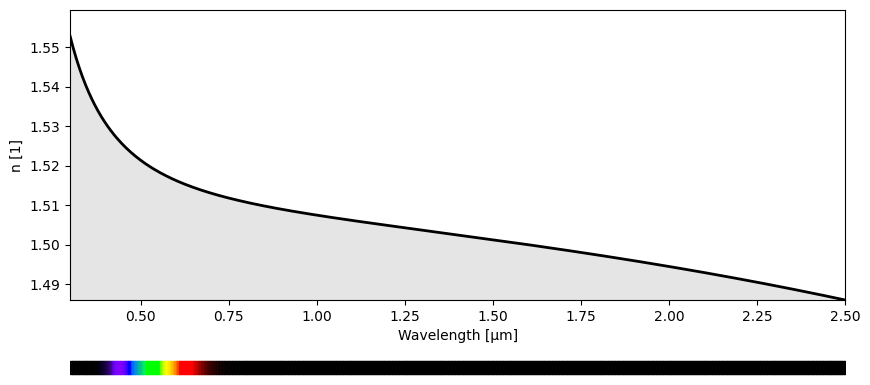

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import diffinytrace as dit
import torch
import numpy as np
torch.set_default_dtype(torch.float64)

aperture_radius = 12.7
NBK7 = dit.materials["NBK7"]
dit.plotting.wavelength.plot(NBK7)


In [2]:
n_enviroment = 1.000293
wave_len = 0.5328

lens_pos1D = 0.5
lens_thickness = 6.5
curvature = 0.05
detector_distance = 25.

grid_size = 32


light_transform = dit.transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_source = dit.source.CollimatedMonochromatic(light_transform,aperture_radius,wave_len)
light_transform.pos.requires_grad = False

lens_transform = dit.transforms.Distance(lens_pos1D,parent_transform=light_transform)
lens_transform.distance.requires_grad = False
surface1 = dit.Aspheric(curvature=curvature)
surface2 = dit.Plane()
lens1 = dit.Lens(lens_transform,lens_thickness,surface1,surface2,NBK7,aperture_radius)
lens1.lens_thickness.requires_grad = False

detector_transform = dit.transforms.Distance(detector_distance)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = dit.Plane()

aperture_radius_det = aperture_radius*0.5
detector = dit.Detector(detector_transform,plane_surface,aperture_radius_det)
#gridxt = torch.linspace(-aperture_radius,aperture_radius,grid_size)
#grid_delta =gridxt[1]-gridxt[0] 


system = dit.SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector})

In [3]:
num_pix = 100
__gridxt = torch.linspace(-aperture_radius_det,aperture_radius_det,num_pix)
print("num_pix",num_pix,"grid_delta",__gridxt[1]-__gridxt[0])


num_pix 100 grid_delta tensor(0.1283)


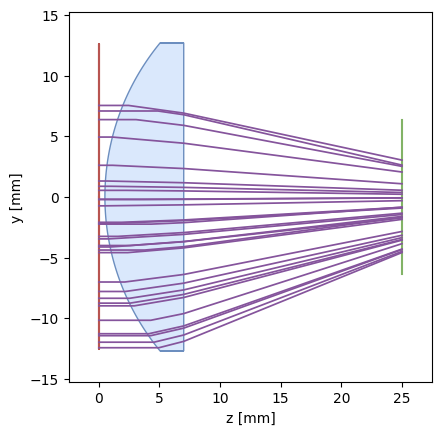

In [4]:

x,weights = light_source.sample(30)
sequence = ["source","lens","detector"]
O,D,wave_len,_,RayPaths = system(x,sequence)

#dit.plotting.system3D.plot(system,RayPaths,show_grid=False)
dit.plotting.system2D.plot(system,RayPaths)

In [5]:
__irrs = []
sigmas = [0.1,0.2,0.5]
for sigma in sigmas:
    smoother = dit.nonimaging.smoothing.GaussianSmootherSquare(aperture_radius_det,num_pix,sigma)
    irr = dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=100000,method_ray_tracing="monte_carlo")
    #dit.plotting.quantity2D.intensity(irr,f"irradiance ($\sigma$={smoother.sigma} mm)",[-aperture_radius,aperture_radius])
    __irrs.append(irr)

In [6]:
import numpy as np
import torch
from diffinytrace.render import binned_irradiance

grid = dit.target_grid.GridSquare(aperture_radius_det,num_pix)
raycounting_list = []
for k in range(20):
    tmp = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=1000000,method_ray_tracing="monte_carlo")
    raycounting_list.append(tmp)
raycounting = torch.mean(torch.stack(raycounting_list),dim=0)

#dit.plotting.quantity2D.intensity(raycounting,f"Ray Counting",[-aperture_radius_det,aperture_radius_det])


_image_from_grid 1 3
[tensor(True), tensor(True), tensor(True), tensor(False)]


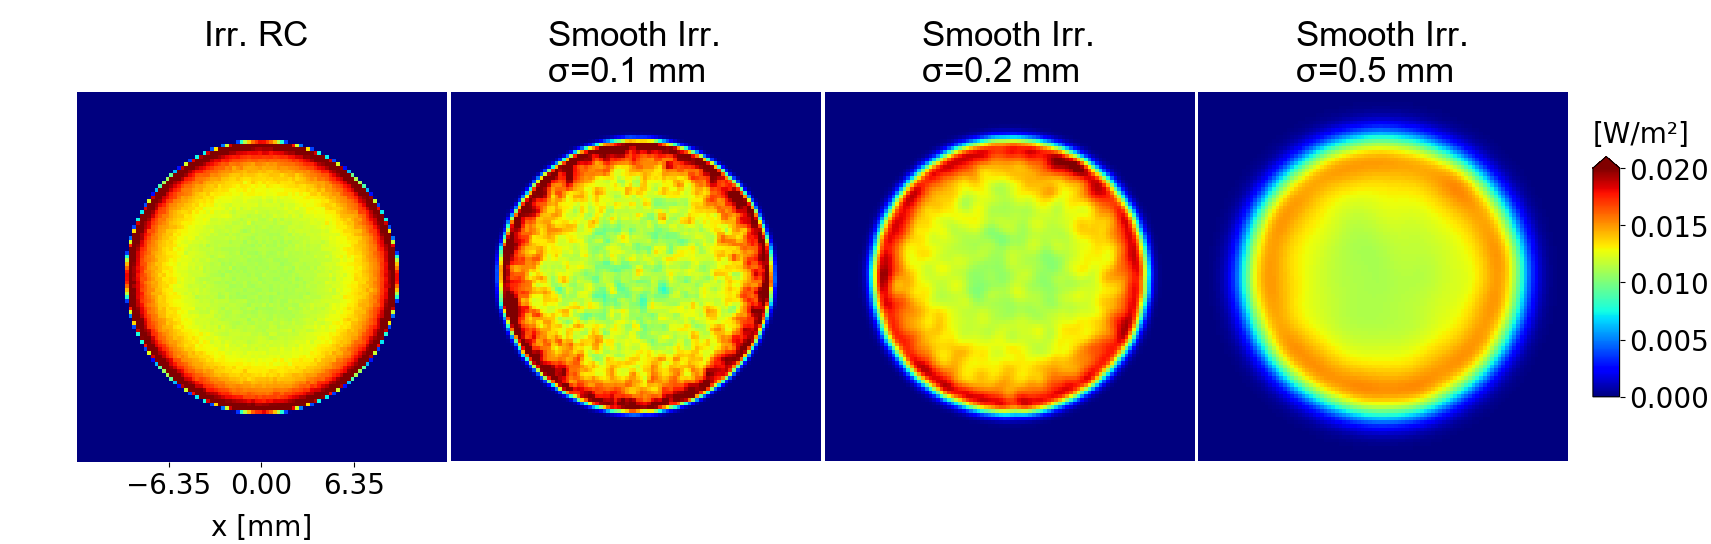

In [7]:
from image_helper import image_from_grid
rows_extent = [[-aperture_radius, aperture_radius, -aperture_radius, aperture_radius]] * len(sigmas)
irrs = [raycounting] + __irrs

irrs = [np.clip(irr,0.0,0.02) for irr in irrs]

image_grid = [irrs]
rows_vidx = [0]
rows_cmap = ["jet"]
cbar_titles = ["[W/m²]"]
columns_title = ["Irr. RC \n "]+[f"Smooth Irr.\nσ={sigma} mm" for sigma in sigmas]
rows_title = [""]
kwargs = dict(image_grid=image_grid,
                rows_extent=rows_extent,
                rows_vidx=rows_vidx,
                rows_cmap=rows_cmap,
                rows_title=rows_title,
                cbar_titles=cbar_titles,
                columns_title=columns_title)
        
out = image_from_grid(**kwargs,
                                max_num_column=5,
                            font_size_PIL=35,
                            cbar_labelsize=20,
                            cbar_title_fontsize=20)
out = out[0]

from PIL import Image, ImageDraw, ImageFont
original_image = Image.open(out)
print([(elem>=0.016).any() for elem in irrs])
original_image
    


In [13]:

    
def run_all_simulations():
    global smoother_baseline_irrs
    
    L2_diff_RC = {}
    L2_diff_smooth = {}

    RMSE_RC = {}
    RMSE_smooth = {}
    
    all_num_rays = np.array(2**np.linspace(10,20,20),dtype=np.int64)
    #,5000,10000
    
    for sigma in sigmas:
        quick_render = lambda num_rays,smoother: dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=num_rays,method_ray_tracing="monte_carlo")
        get_smoother = lambda sigma: dit.nonimaging.smoothing.GaussianSmootherSquare(aperture_radius_det,num_pix,sigma)
        smoother = get_smoother(sigma)
        
        baseline_smooth_irr = []
        for k in range(10):
            baseline_smooth_irr.append(quick_render(100000,smoother))
        
        baseline_smooth_irr = torch.mean(torch.stack(baseline_smooth_irr),dim=0)

        RMSE_RC[sigma] = []
        RMSE_smooth[sigma] = []
        
        L2_diff_RC[sigma] = []
        L2_diff_smooth[sigma] = []
        
        for num_rays in all_num_rays:
            
            #print("after baseline render")
            
            irr = quick_render(num_rays,smoother)
                
            _L2_diff_RC = torch.sqrt(smoother.get_integral_over_distribution((irr-raycounting)**2.0))
            _L2_diff_smooth = torch.sqrt(smoother.get_integral_over_distribution((irr-baseline_smooth_irr)**2.0))
            

            _RMSE_RC = torch.sqrt(torch.mean((irr-raycounting)**2.0))
            _RMSE_smooth = torch.sqrt(torch.mean((irr-baseline_smooth_irr)**2.0))
            
            RMSE_RC[sigma].append(_RMSE_RC)
            RMSE_smooth[sigma].append(_RMSE_smooth)
            
            L2_diff_RC[sigma].append(_L2_diff_RC)
            L2_diff_smooth[sigma].append(_L2_diff_smooth)
                

    return RMSE_RC, RMSE_smooth, L2_diff_RC, L2_diff_smooth,all_num_rays

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np


RMSE_RC, RMSE_smooth, L2_diff_RC, L2_diff_smooth,all_num_rays = run_all_simulations()
# Get the number of different ray counts


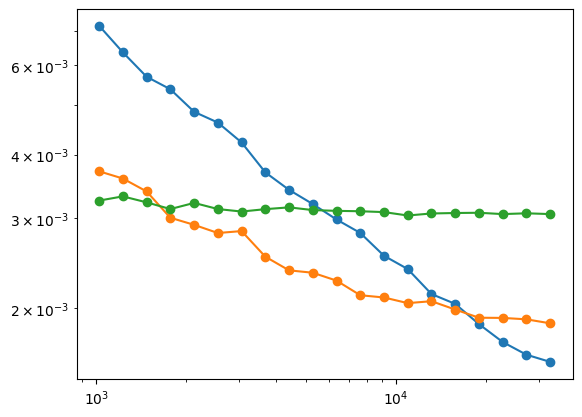

In [ ]:
import matplotlib.pyplot as plt

colors = ['blue', 'green', 'orange', 'purple']
for sigma in RMSE_RC.keys():
    plt.loglog(all_num_rays,RMSE_RC[sigma],'o-',label=f"RC σ={sigma} mm")
